# Projekt 01 (basic): pandas-Grundlagen mit echten Pinguinen

**Ziel:** Die pandas-Grundwerkzeuge an einem echten Datensatz einueben:
laden, inspizieren, filtern, neue Spalten, gruppieren, plotten.

**Die Daten:** 344 Pinguine dreier Arten (Adelie, Chinstrap, Gentoo) von drei Inseln
des Palmer-Archipels (Antarktis), vermessen 2007-2009 von Dr. Kristen Gorman —
ein echter Forschungsdatensatz und das Standard-Uebungsbeispiel der Data-Science-Welt.
Er kommt ueber `seaborn.load_dataset` (beim ersten Aufruf wird er automatisch
heruntergeladen und lokal gecacht).

**So arbeitest du:** Zellen von oben nach unten ausfuehren, `# TODO`-Zellen selbst
vervollstaendigen. Unter vielen Aufgaben steht ein Mini-Check, der `True` ergeben muss.
Musterloesung: `loesung/loesung.ipynb` — erst selbst probieren!

**Bezug zum Skript:** Abschnitte 1.3 (deskriptive Statistik), 1.4 (Plots), 1.5 (pandas).

## 1. Laden und Erstinspektion

Die ersten drei Befehle bei JEDEM neuen Datensatz: `head()`, `info()`, `describe()`.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


**Lies die `info()`-Ausgabe wie ein Profi:**
- 344 Zeilen; `species`, `island`, `sex` sind `object` (Text/Kategorien), der Rest `float64` (metrisch)
- Einige Spalten haben weniger als 344 non-null Werte → es gibt **fehlende Werte**!

**Aufgabe:** Zaehle die fehlenden Werte pro Spalte (`isna()` liefert True/False, `sum()` zaehlt).

In [3]:
fehlend = df.isna().sum()
print(fehlend)

# Mini-Check — muss True ausgeben:
print(int(fehlend.sum()) == 19)

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
True


## 2. Deskriptive Statistik

`describe()` liefert Kennzahlen aller metrischen Spalten auf einen Schlag.
Vergleiche bei `body_mass_g` Mittelwert und Median (= 50 %-Quantil) — liegen sie
nah beieinander, ist die Verteilung halbwegs symmetrisch (Skript 1.3).

In [4]:
df.describe().round(1)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.0,342.0,342.0,342.0
mean,43.9,17.2,200.9,4201.8
std,5.5,2.0,14.1,802.0
min,32.1,13.1,172.0,2700.0
25%,39.2,15.6,190.0,3550.0
50%,44.4,17.3,197.0,4050.0
75%,48.5,18.7,213.0,4750.0
max,59.6,21.5,231.0,6300.0


## 3. Auswaehlen und Filtern

Die zwei Grundmuster:
- Spalte: `df["body_mass_g"]`
- Zeilen per boolescher Maske: `df[df["species"] == "Gentoo"]`

**Aufgaben:**
1. `gentoo`: alle Gentoo-Pinguine
2. `schwer`: alle Pinguine ueber 5000 g
3. `gentoo_biscoe`: alle Gentoo von der Insel Biscoe (zwei Bedingungen: `&` und Klammern um jede Bedingung!)

In [5]:
gentoo = df[df["species"] == "Gentoo"]
schwer = df[df["body_mass_g"] > 5000]
gentoo_biscoe = df[(df["species"] == "Gentoo") & (df["island"] == "Biscoe")]

# Mini-Checks — alle True?
print(len(gentoo) == 124)
print(len(schwer) == 61)
print(len(gentoo_biscoe) == 124)   # Aha: ALLE Gentoo leben auf Biscoe!

True
True
True


## 4. Neue Spalten (vektorisiert!)

Kein `for` ueber Zeilen — ganze Spalten auf einmal (Skript 1.5).

**Aufgaben:**
1. `masse_kg`: Koerpermasse in Kilogramm
2. `schnabel_verhaeltnis`: `bill_length_mm / bill_depth_mm` (ein Formmerkmal)

In [6]:
df["masse_kg"] = df["body_mass_g"] / 1000
df["schnabel_verhaeltnis"] = df["bill_length_mm"] / df["bill_depth_mm"]

# Mini-Check:
print(round(float(df["masse_kg"].max()), 2) == 6.3)
df[["species", "masse_kg", "schnabel_verhaeltnis"]].head(3)

True


,species,masse_kg,schnabel_verhaeltnis
0,Adelie,3.75,2.090909
1,Adelie,3.80,2.270115
2,Adelie,3.25,2.238889


## 5. Gruppieren: das Arbeitspferd

„Unterscheiden sich die Arten?" ist eine `groupby`-Frage (Skript 2.3: Split-Apply-Combine).

**Aufgabe:** Mittlere Koerpermasse (g) pro Art. Danach (vorgegeben): mehrere Kennzahlen
gleichzeitig mit `.agg()`.

In [7]:
masse_pro_art = df.groupby("species")["body_mass_g"].mean()
print(masse_pro_art.round(0))

# Mini-Check: Gentoo ist die mit Abstand schwerste Art
print(masse_pro_art.idxmax() == "Gentoo")

species
Adelie       3701.0
Chinstrap    3733.0
Gentoo       5076.0
Name: body_mass_g, dtype: float64
True


In [8]:
# Mehrere Kennzahlen auf einmal — fertig vorgegeben:
df.groupby("species")["body_mass_g"].agg(["count", "mean", "median", "std"]).round(1)

,count,mean,median,std
species,,,,
Adelie,151,3700.7,3700.0,458.6
Chinstrap,68,3733.1,3700.0,384.3
Gentoo,123,5076.0,5000.0,504.1


## 6. Die Grundplots

Jetzt die drei wichtigsten Plot-Typen aus Skript 1.4 — jede Grafik bekommt
einen Satz Interpretation (steht als Frage dabei).

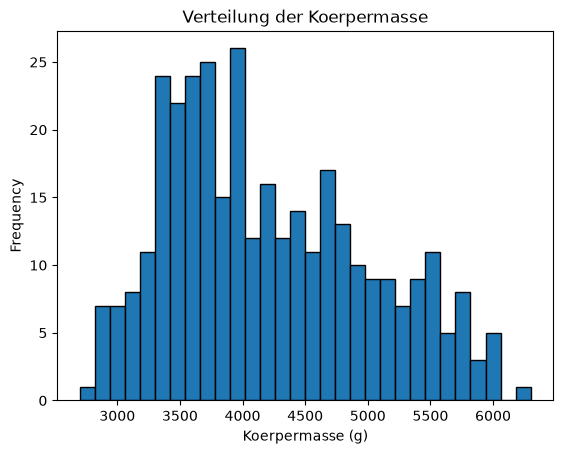

In [9]:
# Histogramm: Wie ist die Koerpermasse verteilt?
df["body_mass_g"].plot.hist(bins=30, edgecolor="black")
plt.xlabel("Koerpermasse (g)"); plt.title("Verteilung der Koerpermasse")
plt.show()
# Frage an dich: Die Verteilung hat zwei "Huegel" (bimodal) — welche Erklaerung
# liefert der groupby aus Schritt 5?

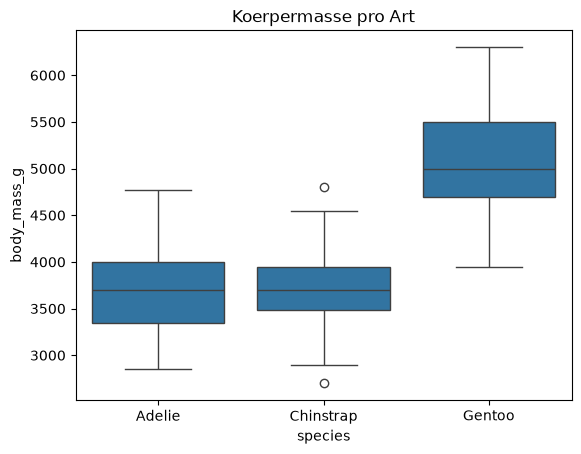

In [10]:
# Boxplot pro Art: Verteilungen VERGLEICHEN
sns.boxplot(data=df, x="species", y="body_mass_g")
plt.title("Koerpermasse pro Art")
plt.show()
# Frage: Passt das Bild zur bimodalen Verteilung von oben?

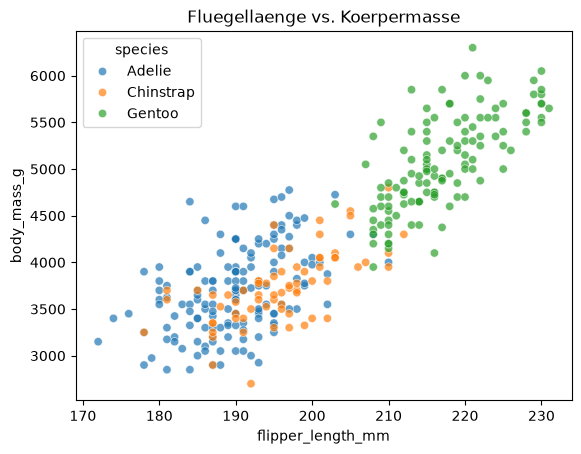

In [11]:
# Scatterplot: Zusammenhang zweier metrischer Variablen, gefaerbt nach Art
sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g", hue="species", alpha=0.7)
plt.title("Fluegellaenge vs. Koerpermasse")
plt.show()
# Frage: Ist der Zusammenhang positiv? Bilden die Arten getrennte Wolken?

## 7. Korrelation

**Aufgabe:** Berechne die Pearson-Korrelation zwischen `flipper_length_mm` und
`body_mass_g` (Methode `.corr()` einer Series mit einer anderen).

In [12]:
r = df["flipper_length_mm"].corr(df["body_mass_g"])
print(f"Pearson r = {r:.3f}")

# Mini-Check: stark positiver Zusammenhang
print(r > 0.85)

Pearson r = 0.871
True


**Interpretation:** $r \approx 0{,}87$ — groessere Fluegel, schwerere Pinguine,
ein klarer, fast linearer Zusammenhang (der Scatterplot bestaetigt das Bild —
Skript 2.4: nie $r$ ohne Plot interpretieren).

## Geschafft — was du jetzt kannst

- Erstinspektion im Schlaf: `head` / `info` / `describe` / `isna().sum()`
- Filtern mit booleschen Masken, auch mehrfach kombiniert
- vektorisierte Spalten, `groupby`-Aggregation
- Histogramm, Boxplot, Scatterplot — und zu jedem eine Aussage

**Bonusaufgaben** (optional):
1. Welche Insel hat die meisten Pinguine? (`value_counts()`)
2. Gibt es Groessenunterschiede zwischen Maennchen und Weibchen *innerhalb* einer Art?
   (`groupby(["species", "sex"])`)
3. Schau dir `schnabel_verhaeltnis` pro Art als Boxplot an — koennte man die Arten
   allein am Schnabel erkennen?